# MINOS U-View Sparse CNN (MIT TorchSparse Engine)

This notebook trains a **simple single-view (U-view)** sparse convolutional neural network (`SimpleUViewSparseCNN`) to classify MINOS **Charged Current (CC)** vs **Neutral Current (NC)** event displays using MIT TorchSparse API (`SparseTensor` and `torchsparse.nn`).

### Features:
1. **Lightweight Dataset Parsing**: Loads U-view event displays (`target_view=2`) from the MINOS ROOT file.
2. **TorchSparse Submanifold Convolutions**: Built on `torchsparse` `SparseTensor` and `spnn.SubMConv2d` layers.
3. **Standard Global Average Pooling**: Aggregates hit features per event using `spnn.GlobalAvgPooling()`.
4. **Inverse Class Reweighting**: Automatically reweights CC vs NC loss.

In [1]:
# Setup, Imports, and Module Reloading
import sys
import importlib
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))

# Purge any stale in-memory cached imports for src
for mod in list(sys.modules.keys()):
    if mod == 'src' or mod.startswith('src.'):
        del sys.modules[mod]

import src
importlib.reload(src)

from src import (
    SparseTensor,
    MINOSSingleViewDataset,
    create_uview_dataloaders,
    SimpleUViewSparseCNN,
    train_model,
    validate_epoch
)
import src.torchsparse.nn as spnn

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using PyTorch device: {device}')
print('TorchSparse API (SparseTensor & torchsparse.nn) loaded successfully!')

Using PyTorch device: cpu
TorchSparse API (SparseTensor & torchsparse.nn) loaded successfully!


## 1. Load U-View MINOS Dataset & DataLoaders

In [2]:
root_filepath = '/home/philip/UCL/minos/f21048000_0000_L010185N_D07_r3.sntp.dogwood5.0.root'

dataset = MINOSSingleViewDataset(root_filepath=root_filepath, max_events=12000, target_view=2)
train_loader, val_loader, _, _ = create_uview_dataloaders(dataset, batch_size=32, val_split=0.20, random_seed=42)
class_weights = dataset.get_class_weights(device=device)

print(f'Dataset size: {len(dataset)} U-view events')
print(f'Class Weights -> NC (0): {class_weights[0]:.2f} | CC (1): {class_weights[1]:.2f}')

Dataset size: 11813 U-view events
Class Weights -> NC (0): 2.06 | CC (1): 0.66


## 2. Model Initialization & Training (`SimpleUViewSparseCNN`)

In [3]:
model = SimpleUViewSparseCNN(
    in_channels=1,
    conv_channels=[16, 32],
    fc_dims=[16],
    dropout=0.1
)

print(f'SimpleUViewSparseCNN Total Trainable Parameters: {model.get_num_params():,}')

history, best_metrics = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
    class_weights=class_weights,
    device=device,
    verbose=True
)

SimpleUViewSparseCNN Total Trainable Parameters: 5,458
Starting TorchSparse model training on cpu (10 epochs)...
Epoch [01/10] | Train Loss: 0.5613 Acc: 72.26% | Val Loss: 0.5065 Acc: 73.62% F1: 0.8010 AUC: 0.8476
Epoch [02/10] | Train Loss: 0.4784 Acc: 79.20% | Val Loss: 0.4748 Acc: 80.91% F1: 0.8667 AUC: 0.8594
Epoch [03/10] | Train Loss: 0.4705 Acc: 80.15% | Val Loss: 0.4700 Acc: 80.36% F1: 0.8605 AUC: 0.8655
Epoch [04/10] | Train Loss: 0.4615 Acc: 80.34% | Val Loss: 0.4635 Acc: 79.89% F1: 0.8565 AUC: 0.8677
Epoch [05/10] | Train Loss: 0.4577 Acc: 80.86% | Val Loss: 0.4955 Acc: 73.62% F1: 0.7977 AUC: 0.8736
Epoch [06/10] | Train Loss: 0.4519 Acc: 80.47% | Val Loss: 0.4471 Acc: 81.92% F1: 0.8745 AUC: 0.8816
Epoch [07/10] | Train Loss: 0.4484 Acc: 80.93% | Val Loss: 0.4512 Acc: 82.13% F1: 0.8768 AUC: 0.8765
Epoch [08/10] | Train Loss: 0.4469 Acc: 81.02% | Val Loss: 0.4456 Acc: 78.75% F1: 0.8454 AUC: 0.8827
Epoch [09/10] | Train Loss: 0.4380 Acc: 81.22% | Val Loss: 0.4398 Acc: 81.58% F

## 3. Training & Validation Performance Curves

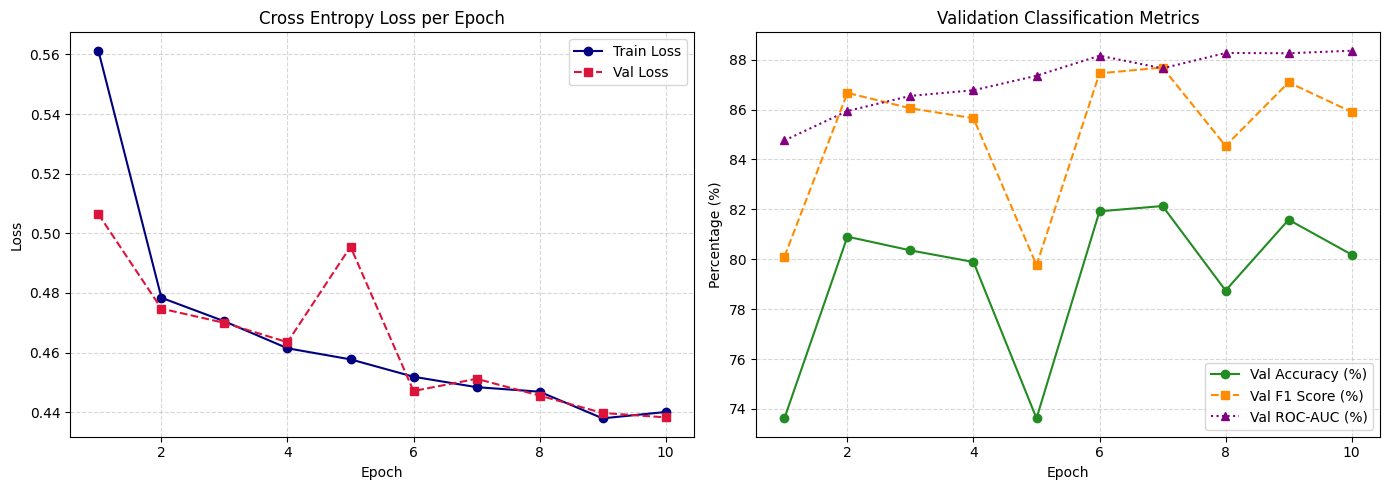

In [4]:
epochs = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(epochs, history['train_loss'], 'o-', label='Train Loss', color='navy')
ax1.plot(epochs, history['val_loss'], 's--', label='Val Loss', color='crimson')
ax1.set_title('Cross Entropy Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# Accuracy & F1 curves
ax2.plot(epochs, [a * 100 for a in history['val_acc']], 'o-', label='Val Accuracy (%)', color='forestgreen')
ax2.plot(epochs, [f * 100 for f in history['val_f1']], 's--', label='Val F1 Score (%)', color='darkorange')
ax2.plot(epochs, [a * 100 for a in history['val_auc']], '^:', label='Val ROC-AUC (%)', color='purple')
ax2.set_title('Validation Classification Metrics')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Percentage (%)')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()